In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, f1_score,
                              roc_auc_score, confusion_matrix,
                              roc_curve)
import joblib
import os

# loading the dataset
df = pd.read_csv('data/WA_Fn-UseC_-Telco-Customer-Churn.csv')
print("Shape:", df.shape)
print("Columns:", df.columns.tolist())
df.head()

Shape: (7043, 21)
Columns: ['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [7]:
# checking data types and missing values before doing anything
print("Data Types:")
print(df.dtypes)
print("\nMissing Values:")
print(df.isnull().sum())

# how many customers churned vs stayed
print("\nChurn Distribution:")
print(df['Churn'].value_counts())
print("\nChurn Percentage:")
print(df['Churn'].value_counts(normalize=True) * 100)

Data Types:
customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges            str
Churn                   str
dtype: object

Missing Values:
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling 

In [8]:
# TotalCharges is supposed to be numeric but it came in as a string
# this happens because some rows have empty strings instead of numbers
print("Empty strings found:", df[df['TotalCharges'].str.strip() == ''].shape[0])

# converting to numeric — empty strings become NaN automatically
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# these 11 rows are new customers with zero tenure — dropping them
df = df.dropna(subset=['TotalCharges'])
print("Shape after cleaning:", df.shape)

Empty strings found: 11
Shape after cleaning: (7032, 21)


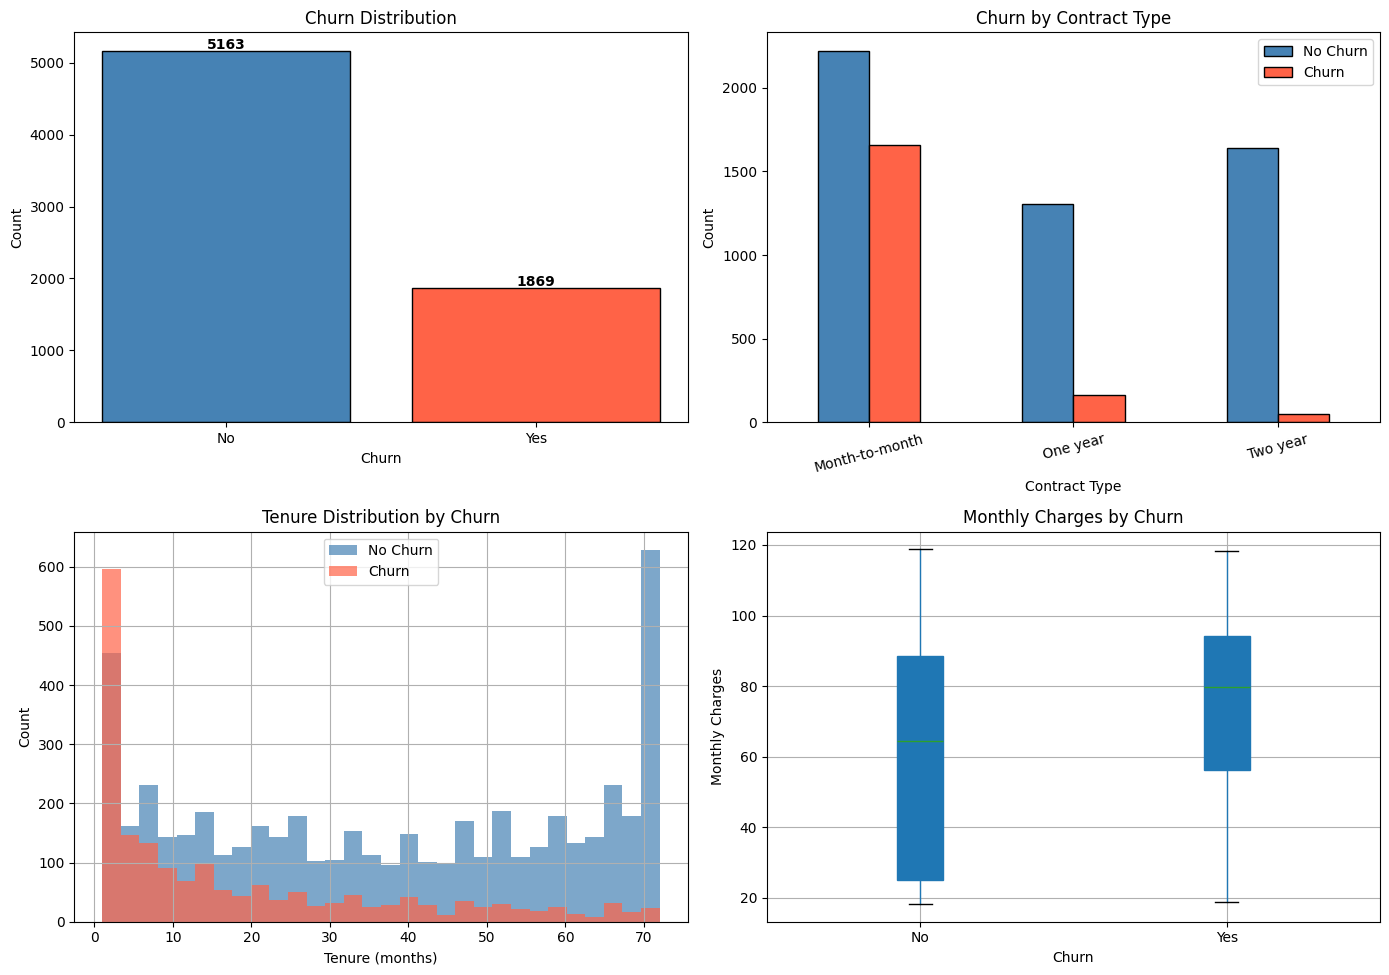

In [9]:
# plotting 4 charts to understand the data before building any model
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Customer Churn Analysis', fontsize=16, fontweight='bold')

# chart 1 — overall churn distribution
churn_counts = df['Churn'].value_counts()
axes[0, 0].bar(churn_counts.index, churn_counts.values,
               color=['steelblue', 'tomato'], edgecolor='black')
axes[0, 0].set_title('Churn Distribution')
axes[0, 0].set_xlabel('Churn')
axes[0, 0].set_ylabel('Count')
for i, v in enumerate(churn_counts.values):
    axes[0, 0].text(i, v + 30, str(v), ha='center', fontweight='bold')

# chart 2 — does contract type affect churn?
contract_churn = df.groupby(['Contract', 'Churn']).size().unstack()
contract_churn.plot(kind='bar', ax=axes[0, 1],
                    color=['steelblue', 'tomato'], edgecolor='black', rot=15)
axes[0, 1].set_title('Churn by Contract Type')
axes[0, 1].set_xlabel('Contract Type')
axes[0, 1].set_ylabel('Count')
axes[0, 1].legend(['No Churn', 'Churn'])

# chart 3 — do newer customers leave more?
df[df['Churn'] == 'No']['tenure'].hist(ax=axes[1, 0], bins=30,
                                        alpha=0.7, color='steelblue', label='No Churn')
df[df['Churn'] == 'Yes']['tenure'].hist(ax=axes[1, 0], bins=30,
                                         alpha=0.7, color='tomato', label='Churn')
axes[1, 0].set_title('Tenure Distribution by Churn')
axes[1, 0].set_xlabel('Tenure (months)')
axes[1, 0].set_ylabel('Count')
axes[1, 0].legend()

# chart 4 — do higher paying customers leave more?
df.boxplot(column='MonthlyCharges', by='Churn', ax=axes[1, 1], patch_artist=True)
axes[1, 1].set_title('Monthly Charges by Churn')
axes[1, 1].set_xlabel('Churn')
axes[1, 1].set_ylabel('Monthly Charges')
plt.suptitle('')

plt.tight_layout()
plt.savefig('churn_eda.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# customerID is just an identifier — not useful for prediction
df = df.drop(columns=['customerID'])

# converting target to 0 and 1 so the model can work with it
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

# these columns are simple yes/no so converting directly to 0 and 1
binary_cols = ['Partner', 'Dependents', 'PhoneService', 'PaperlessBilling']
for col in binary_cols:
    df[col] = df[col].map({'Yes': 1, 'No': 0})

# some columns have a third value like 'No internet service'
# treating that the same as 'No' to simplify
cols_with_no_service = [
    'MultipleLines', 'OnlineSecurity', 'OnlineBackup',
    'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies'
]
for col in cols_with_no_service:
    df[col] = df[col].replace({
        'No internet service': 'No',
        'No phone service': 'No'
    })
    df[col] = df[col].map({'Yes': 1, 'No': 0})

# columns with more than 2 categories need one-hot encoding
# drop_first=True avoids the dummy variable trap
cat_cols = ['gender', 'InternetService', 'Contract', 'PaymentMethod']
df = pd.get_dummies(df, columns=cat_cols, drop_first=True)

# get_dummies creates bool columns — converting to int for sklearn
df = df.astype({col: int for col in df.select_dtypes(include='bool').columns})

print("Shape after encoding:", df.shape)
print("Column types:", df.dtypes.value_counts())

In [15]:
X = df.drop(columns=['Churn'])
y = df['Churn']

# saving feature column names — needed later in the Streamlit app
feature_cols = X.columns.tolist()

# 80/20 split — stratify keeps the same churn ratio in both sets
# without stratify, random split could give uneven churn distribution
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# scaling so no feature dominates due to large value range
# fit only on training data — never on test data (would cause data leakage)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Train size:", X_train_scaled.shape)
print("Test size:", X_test_scaled.shape)
print("Churn rate train:", y_train.mean().round(3))
print("Churn rate test:", y_test.mean().round(3))

Train size: (5625, 23)
Test size: (1407, 23)
Churn rate train: 0.266
Churn rate test: 0.266


In [16]:
# trying two models to compare — starting simple with Logistic Regression
lr = LogisticRegression(max_iter=1000, random_state=42, solver='lbfgs')
lr.fit(X_train_scaled, y_train)
lr_pred = lr.predict(X_test_scaled)
lr_prob = lr.predict_proba(X_test_scaled)[:, 1]

# Random Forest as a second model — handles non-linear patterns
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train_scaled, y_train)
rf_pred = rf.predict(X_test_scaled)
rf_prob = rf.predict_proba(X_test_scaled)[:, 1]

# comparing on accuracy, F1, and AUC-ROC
# accuracy alone is misleading for imbalanced data — using all three
models = {
    'Logistic Regression': (lr_pred, lr_prob),
    'Random Forest': (rf_pred, rf_prob)
}

print("=" * 55)
print(f"{'Model':<25} {'Accuracy':>8} {'F1':>8} {'AUC-ROC':>8}")
print("=" * 55)
for name, (pred, prob) in models.items():
    acc = accuracy_score(y_test, pred)
    f1 = f1_score(y_test, pred)
    auc = roc_auc_score(y_test, prob)
    print(f"{name:<25} {acc:>8.3f} {f1:>8.3f} {auc:>8.3f}")
print("=" * 55)

Model                     Accuracy       F1  AUC-ROC
Logistic Regression          0.804    0.609    0.836
Random Forest                0.790    0.560    0.818


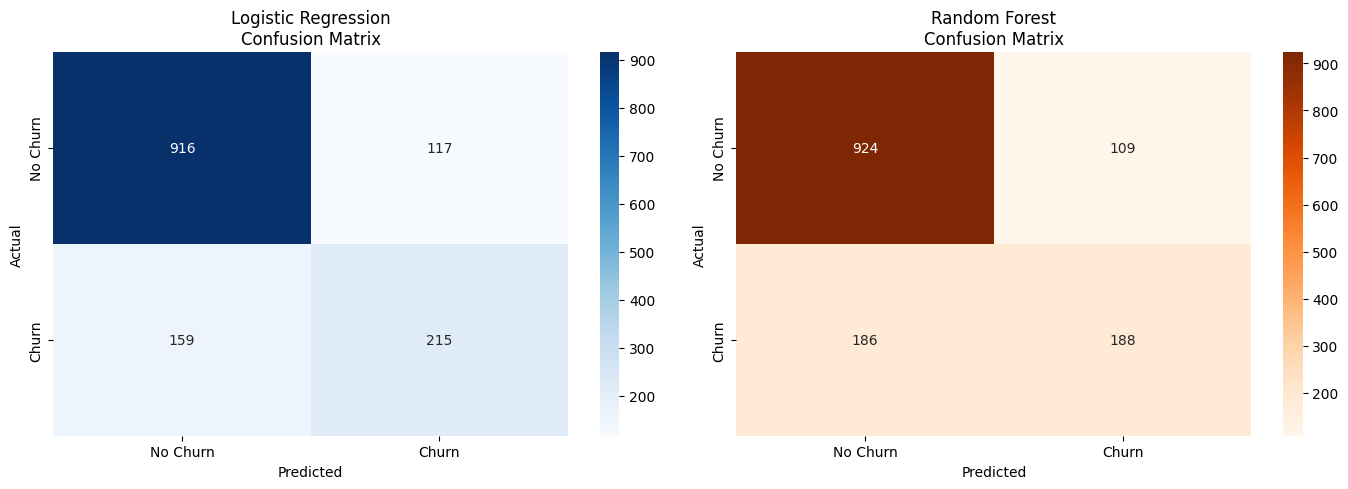

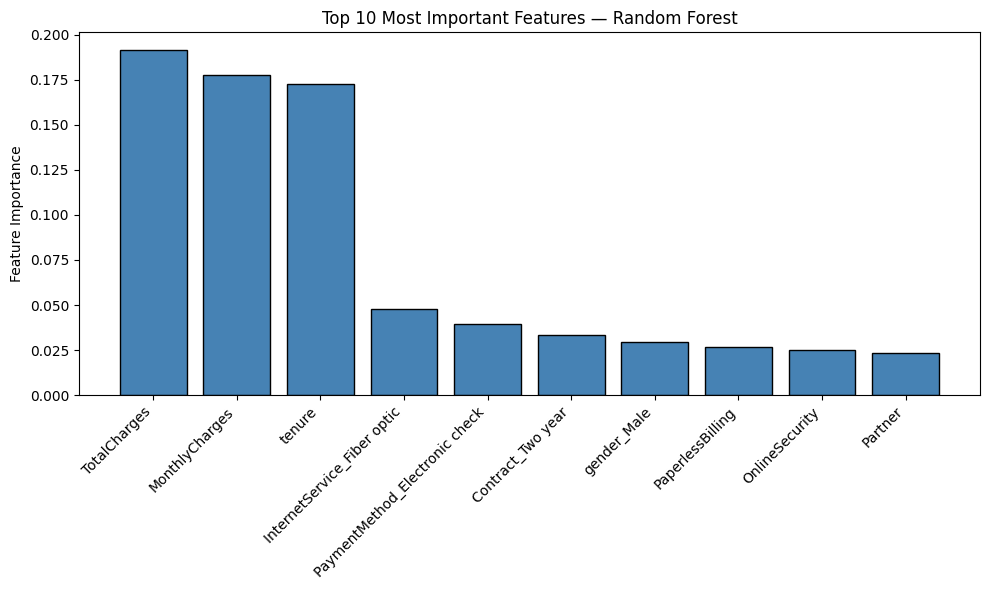

In [17]:
# confusion matrix shows exactly where the model gets it right and wrong
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cm_lr = confusion_matrix(y_test, lr_pred)
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['No Churn', 'Churn'],
            yticklabels=['No Churn', 'Churn'])
axes[0].set_title('Logistic Regression\nConfusion Matrix')
axes[0].set_ylabel('Actual')
axes[0].set_xlabel('Predicted')

cm_rf = confusion_matrix(y_test, rf_pred)
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Oranges', ax=axes[1],
            xticklabels=['No Churn', 'Churn'],
            yticklabels=['No Churn', 'Churn'])
axes[1].set_title('Random Forest\nConfusion Matrix')
axes[1].set_ylabel('Actual')
axes[1].set_xlabel('Predicted')

plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

# feature importance from Random Forest shows what actually drives churn
importances = rf.feature_importances_
indices = np.argsort(importances)[::-1][:10]

plt.figure(figsize=(10, 6))
plt.bar(range(10), importances[indices], color='steelblue', edgecolor='black')
plt.xticks(range(10), [feature_cols[i] for i in indices], rotation=45, ha='right')
plt.title('Top 10 Most Important Features — Random Forest')
plt.ylabel('Feature Importance')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

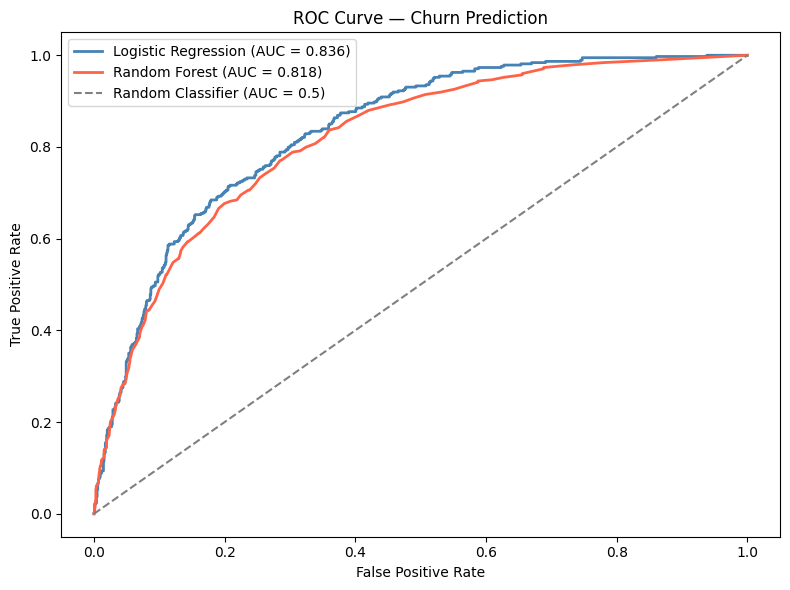

In [18]:
# ROC curve shows how well the model separates churners from non-churners
# the closer to the top-left corner, the better
fpr_lr, tpr_lr, _ = roc_curve(y_test, lr_prob)
fpr_rf, tpr_rf, _ = roc_curve(y_test, rf_prob)

plt.figure(figsize=(8, 6))
plt.plot(fpr_lr, tpr_lr, color='steelblue', linewidth=2,
         label='Logistic Regression (AUC = 0.836)')
plt.plot(fpr_rf, tpr_rf, color='tomato', linewidth=2,
         label='Random Forest (AUC = 0.818)')

# diagonal line represents a random classifier — our model should be above this
plt.plot([0, 1], [0, 1], color='gray', linestyle='--',
         label='Random Classifier (AUC = 0.5)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve — Churn Prediction')
plt.legend()
plt.tight_layout()
plt.savefig('roc_curve.png', dpi=150, bbox_inches='tight')
plt.show()

In [19]:
# saving the model, scaler, and feature names
# all three are needed to make predictions on new data in the Streamlit app
os.makedirs('model', exist_ok=True)

joblib.dump(lr, 'model/churn_model.pkl')
joblib.dump(scaler, 'model/scaler.pkl')
joblib.dump(feature_cols, 'model/feature_names.pkl')

print("Model saved successfully.")
print("Feature columns saved:", len(feature_cols))

Model saved successfully.
Feature columns saved: 23
